# STPath — zero-shot generative foundation model

STPath (Huang et al., *npj Digital Medicine* 2025) is a
generative foundation model trained on 1,170 paired ST + H&E
slides covering **17 organs and 38,984 genes**. The published
weights (HuggingFace [`tlhuang/STPath`](https://huggingface.co/tlhuang/STPath))
take only GigaPath features and tile centroids as input — no
reference Visium slide is required, no per-slide
fine-tuning. On HEST-Bench it leads the next best method by
**+6.9 % Pearson**.

This makes STPath the right pick when you have an **H&E-only**
slide of a tissue covered by its training mixture (any of the
17 organs × Visium / Visium-HD / Xenium / CosMx) and want
spot-level expression without doing any per-slide training.
For organs / panels outside its vocabulary use HEST-FM (with
a paired reference) or STFlow (per-slide fine-tune).

**HuggingFace access** — `prov-gigapath/prov-gigapath` (used
to extract the 1536-d patch features STPath expects) is gated.
Request access at <https://huggingface.co/prov-gigapath/prov-gigapath>,
wait for the Microsoft Research approval email, then
`huggingface-cli login` with a token that includes that
agreement. Without it the embed cell raises `GatedRepoError`.

## Environment

In [1]:
import warnings
warnings.filterwarnings('ignore')

import omicverse as ov
import lazyslide as zs
ov.utils.ov_plot_set()

print('omicverse', ov.__version__, '| lazyslide', zs.__version__)

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1 | lazyslide 0.9.2


## Inputs STPath expects

STPath needs only a tiled WSI; *no Visium reference*. Concretely:

- **`wsi` — `wsidata.WSIData`** wrapping the H&E.
- **GigaPath tile features** in `wsi.tables['gigapath_tiles']`
  — produced by `ov.space.histo.embed(wsi, model='gigapath')`.
  GigaPath outputs are 1536-dimensional, matching the
  dimensionality STPath was trained on; substituting other
  backbones is not supported.
- **organ token** (e.g. `'Breast'`, `'Kidney'`, `'Lung'`,
  `'Colon'`, `'Liver'`, …, one of STPath's 17 organs). Passing
  the wrong organ degrades quality; passing `None` falls back
  to a generic `'Others'` token.
- **technology token** (`'Visium'`, `'Visium-HD'`, `'Xenium'`,
  `'CosMx'`, …). Defaults to `'Visium'`.

For a real H&E-only slide:

```python
wsi = ov.space.histo.open_wsi('/path/to/slide.tif')
ov.space.histo.tile(wsi, tile_px=224, mpp=0.5)
ov.space.histo.embed(wsi, model='gigapath', batch_size=16)
```

The demo below uses the breast Visium slide for direct
head-to-head comparison with the other HE-zoo tutorials; the
Visium counts are not used by STPath, only the H&E.

## Load the demo dataset

In [2]:
adata, wsi = ov.space.histo.load_breast()
ov.space.histo.tile(wsi, tile_px=224, mpp=0.5)
print('tiles:', len(wsi.shapes['tiles']))

tiles: 1426


## Extract GigaPath features (1536-d, gated)

GigaPath is a 1.1 B-parameter pathology FM (Microsoft Research
+ Providence Health). LazySlide's `feature_extraction` handles
the gated download and HF auth for us. On first run it
downloads ~4 GB of weights into `$HF_HOME/hub`; subsequent
runs use the cache. The resulting features are stored as
`wsi.tables['gigapath_tiles']` (AnnData with one row per tile
and 1536 feature columns) and are also cached to
`$OV_HISTO_CACHE/tile_features/` so notebook re-runs skip
the embed entirely.

In [3]:
ov.space.histo.embed(wsi, model='gigapath',
                     batch_size=16, num_workers=0)
wsi.tables['gigapath_tiles']

AnnData object with n_obs × n_vars = 1426 × 1536
    obs: 'tile_id', 'library_id'
    uns: 'spatialdata_attrs'

## Zero-shot prediction

`predict_expression(method='stpath', …)` does the following
under the hood:

1. on first use, auto-clones the upstream STPath repo into
   `$OV_HISTO_CACHE/STPath/` and adds it to `sys.path`,
2. downloads the model weights (`tlhuang/STPath/stfm.pth`)
   via HuggingFace Hub,
3. instantiates `STPathInference` (gene vocabulary +
   organ / tech tokenizers + the spatial-transformer
   denoiser),
4. feeds `(gigapath features, tile centroids, organ id,
   tech id)` through the model in a single forward pass,
5. wraps the result in an `AnnData` and stores it as
   `wsi.tables['stpath_tiles']`.

### Key parameters

- `organ='Breast'` — STPath's organ-conditioning token. Pick
  one of the 17 organs the model was trained on (`Breast`,
  `Kidney`, `Lung`, `Colon`, `Liver`, …). Wrong organ ⇒
  degraded quality.
- `tech='Visium'` — sequencing platform token; defaults to
  `'Visium'`. Other choices include `'Visium-HD'`, `'Xenium'`,
  `'CosMx'`.
- `genes=['EPCAM', 'ERBB2', …]` — gene panel to keep. Passing
  `None` returns all 38,984 genes from STPath's vocabulary
  (`pred.X` becomes a 1426 × 38,984 dense matrix, ~150 MB —
  fine on disk but heavier in memory).
- `fm_backbone='gigapath'` — must stay `gigapath`; the
  published weights were trained on 1536-d GigaPath features
  specifically.
- `feature_key=None` — override only if you stored GigaPath
  features under a non-default key.
- `cache_dir` — override the default
  `$OV_HISTO_CACHE` (where the STPath repo + weights cache).

In [4]:
pred = ov.space.histo.predict_expression(
    wsi,
    method='stpath',
    organ='Breast',
    tech='Visium',
    genes=['EPCAM', 'ERBB2', 'CD68', 'ACTA2', 'VIM'],
)
pred

n_genes: 38984, n_tech: 5, n_species: 6, n_organs: 25, n_cancer_annos: 5, n_domain_annos: 10
Model loaded from /scratch/users/steorra/cache/omicverse_histo/hf/models--tlhuang--STPath/snapshots/3346881771f2ddb5575532df3df1b5477846d10a/stfm.pth
Starting inference...
Return results...


AnnData object with n_obs × n_vars = 1426 × 5
    obs: 'tile_id', 'library_id'
    uns: 'histo'
    obsm: 'spatial'

## Reading the output

`pred` is an `AnnData` with:

- `pred.X` (n_tiles × n_genes) — log1p predicted expression
  (`float32`)
- `pred.var_names` — the requested gene symbols
- `pred.obsm['spatial']` (n_tiles × 2) — tile pixel centroids
- `pred.uns['histo']` — run metadata (`method`,
  `fm_backbone`, `organ`, `tech`)

In [5]:
print('shape       :', pred.shape)
print('var_names   :', list(pred.var_names))
print('coords range:', pred.obsm['spatial'].min(0), '→',
                       pred.obsm['spatial'].max(0))
print('metadata    :', pred.uns['histo'])

shape       : (1426, 5)
var_names   : ['EPCAM', 'ERBB2', 'CD68', 'ACTA2', 'VIM']
coords range: [4468.5 4355.5] → [22223.5 23521.5]
metadata    : {'method': 'stpath', 'fm_backbone': 'gigapath', 'organ': 'Breast', 'tech': 'Visium'}


## Visualise predictions on the tissue

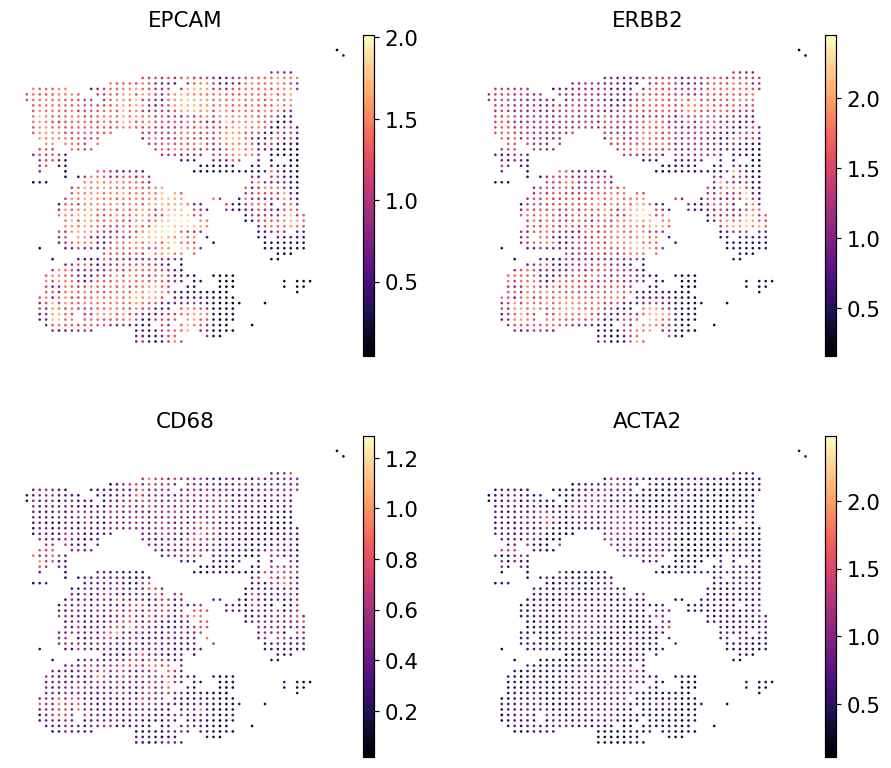

In [6]:
import scanpy as sc
sc.pl.embedding(pred, basis='spatial',
                color=['EPCAM', 'ERBB2', 'CD68', 'ACTA2'],
                cmap='magma', s=12, ncols=2, frameon=False)

## Where to go next

STPath's output is interchangeable with a real Visium table.
Feed it straight to `ov.space.pySTAGATE`, `ov.space.svg`, or
any other spatial analysis. For pixel-level / sub-spot
resolution on the same H&E, switch to
[iStar](t_histo_istar.ipynb) (requires the matched Visium
counts as a reference). For benchmarking against a Ridge
baseline on the same panel, see
[HEST-FM](t_histo_hest_fm.ipynb).